# DispersionWellenpaket


Program demonstrates the dispersion of a Gaussian wave packet.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Parameters

### Spatial coordinate $x$:

$$x \in [-x_{end}/10, 9 x_{end}/10], \quad \Delta x = x_{end}/xsteps$$

### Time coordinate $t$:

$$t \in [-t_{end}, t_{end}], \quad \Delta t = t_{end}/tsteps$$

In [2]:
# Parameters for spatial coordinate x
xend   = 4000
xsteps = 40000
x      = np.linspace(-xend/10, xend*9/10, xsteps)
deltax = xend / xsteps
x0     = 100
b      = 15                    # initial width in meters

# Parameters for time coordinate t
tend   = 200
tsteps = 40000
t = np.linspace(-tend, tend, tsteps)
deltat = tend / tsteps
t0     = 0                     # initial pulse width

# Wave properties
vph0    = 10.0                 # mean phase velocity in m/s
vd      = -5                   # dispersion parameter in m/s
lambda0 = 4.0                  # wavelength in meters
k0      = 2 * np.pi / lambda0  # wave number in 1/m
omega0  = k0 * vph0

## Initial Wave Packet and Spectrum

$$\psi(x) = \exp\left[-\left(\frac{x-x_0}{b}\right)^2\right] e^{ik_0 x}$$
$$\Psi(k) = \mathcal{F}\{\psi(x)\}$$

In [3]:
# Calculation of initial wave packet
psi_inp = np.exp(-((x - x0)/b)**2) * np.exp(1j*k0*x)

# Fourier transform
PSI_inp = np.fft.fft(psi_inp)
PSI_shift = np.fft.fftshift(psi_inp)

# Wave numbers
kx = 1 / (deltax * xsteps)  # spacing in k-space
kz = np.arange(xsteps)
kw = 2 * np.pi * kx * kz  # Wave number in 1/m

# Phase velocity and angular frequency
vph = vph0 + vd * (np.abs(kw) - k0)/k0
# To ensure right-moving wave, omega > 0
omega = -np.abs(vph * kw)
omega[kw > 0] = -omega[kw > 0]

## Control Plot of Dispersion Relation

$$\omega(k) = v_{ph}(k) k$$

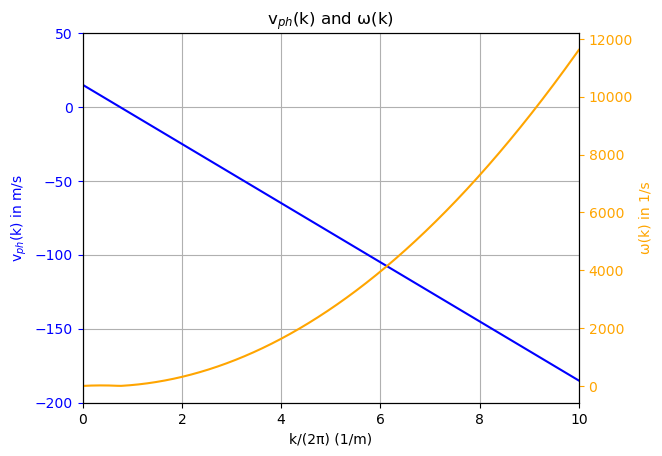

In [4]:
plt.figure("Dispersion Relation")
ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.plot(kw/(2*np.pi), vph, color='blue', label='v_ph(k)')
ax1.set_ylabel("v$_{ph}$(k) in m/s", color='blue')
ax1.set_xlabel("k/(2π) (1/m)")
ax1.set_xlim([0, 10])
ax1.set_ylim([-200, 50])
ax1.tick_params(axis='y', colors='blue')
ax1.autoscale(enable=False)

ax2.plot(kw/(2*np.pi), omega, color='orange', label='ω(k)')
ax2.set_ylabel("ω(k) in 1/s", color='orange')
ax2.tick_params(axis='y', colors='orange')

ax1.grid(True)
plt.title("v$_{ph}$(k) and ω(k)")
plt.show()

## Wave Packet at Two Different Times

$$\Psi(k,t) = \Psi(k,0) e^{-i \omega(k) t}$$

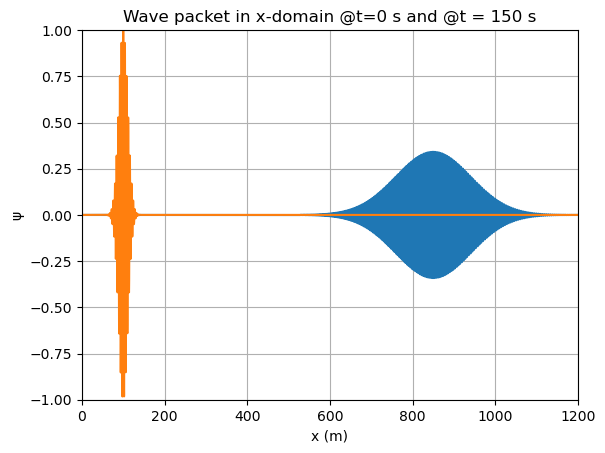

In [5]:
tmess = 150  # time in seconds
tmess_str = f't = {tmess:.5g} s'

plt.figure("Wave packet at two different times")
plt.plot(x, np.real(np.fft.ifft(PSI_inp * np.exp(-1j * omega * tmess))))
plt.plot(x, np.real(psi_inp))
plt.axis([0, 1200, -1, 1])
plt.grid(True)
plt.xlabel("x (m)")
plt.ylabel("ψ")
plt.title(f"Wave packet in x-domain @t=0 s and @{tmess_str}")
plt.show()

## Spectrum of the Wave Packet

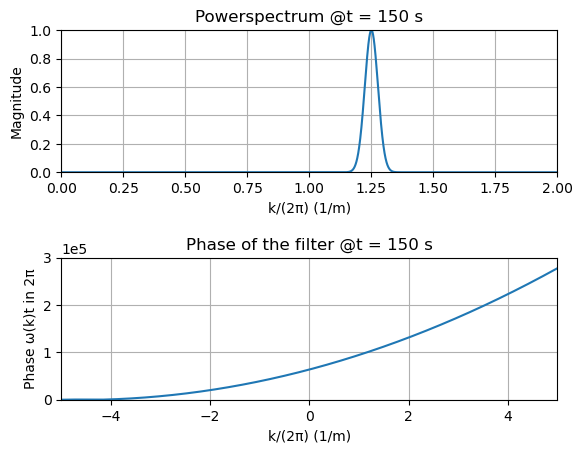

In [6]:
plt.figure("Wave packet Spectrum")

# FFT spectrum
plt.subplot(2,1,1)
kx_axis = kx * np.arange(-xsteps//2, xsteps//2)
plt.plot(kx_axis, np.abs(PSI_shift))
plt.title(f"Powerspectrum @{tmess_str}")
plt.xlabel("k/(2π) (1/m)")
plt.ylabel("Magnitude")
plt.axis([0, 2, None, None])
plt.ylim([0, 1])
plt.grid(True)

plt.subplots_adjust(hspace=0.6)

# Filter spectrum (phase)
plt.subplot(2,1,2)
plt.plot(kx_axis, omega*tmess/(2*np.pi))
plt.title(f"Phase of the filter @{tmess_str}")
plt.xlabel("k/(2π) (1/m)")
plt.ylabel("Phase ω(k)t in 2π")
plt.axis([-5, 5, 0, 3e5])
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.grid(True)
plt.show()

## Simulation of Wave Packet Propagation

$$\psi(x,t) = \mathcal{F}^{-1}[\Psi(k,0) e^{-i \omega(k) t}]$$

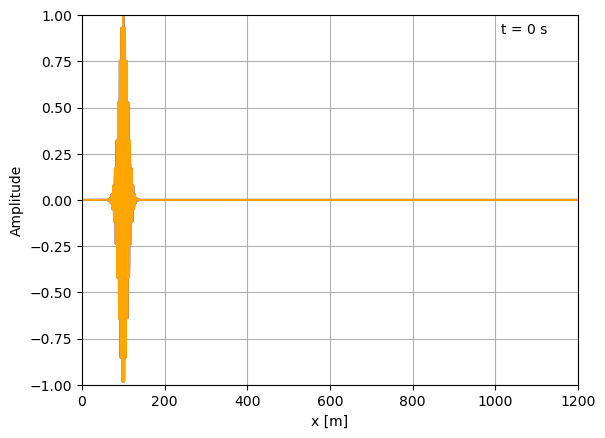

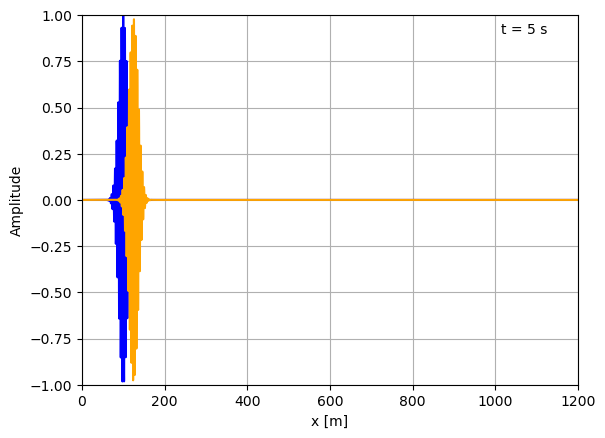

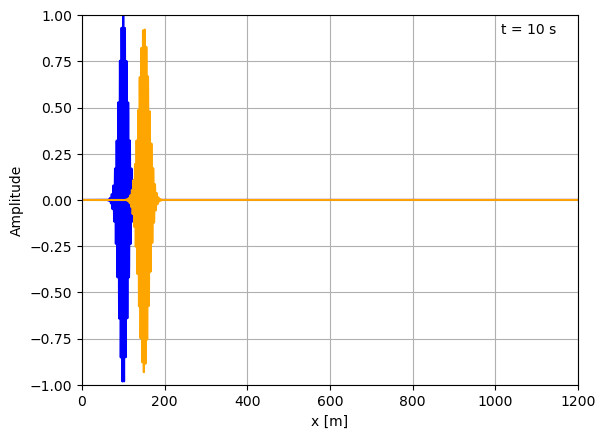

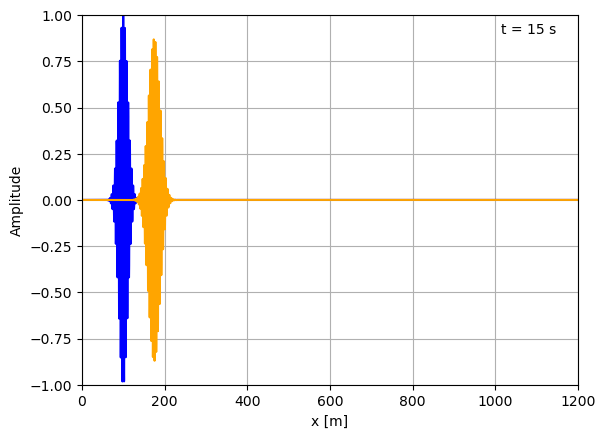

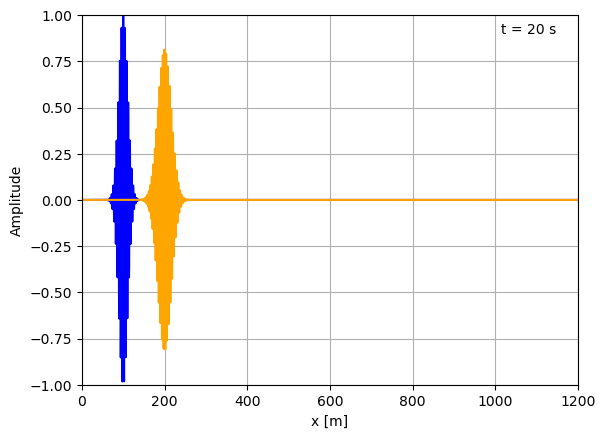

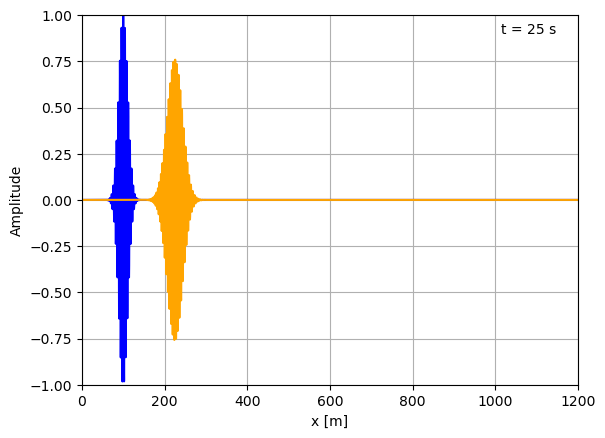

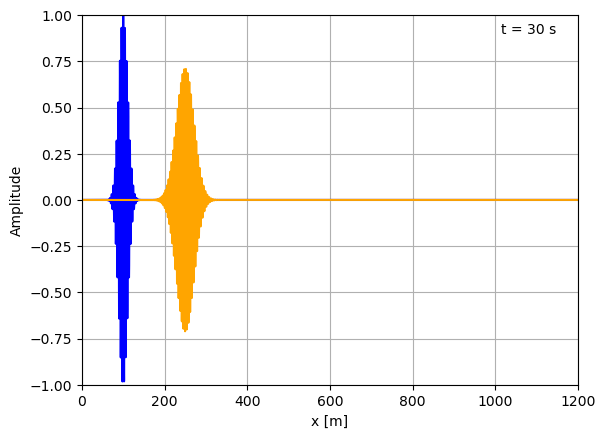

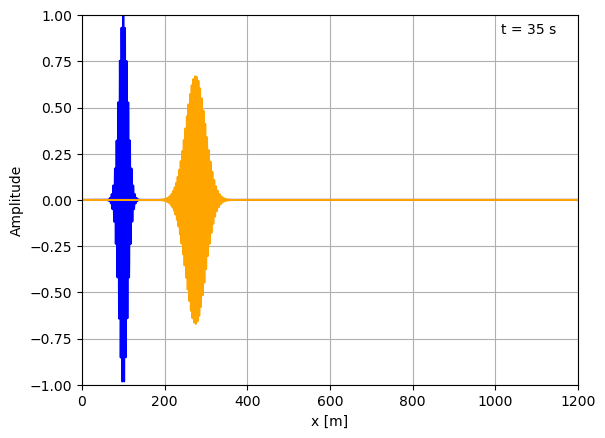

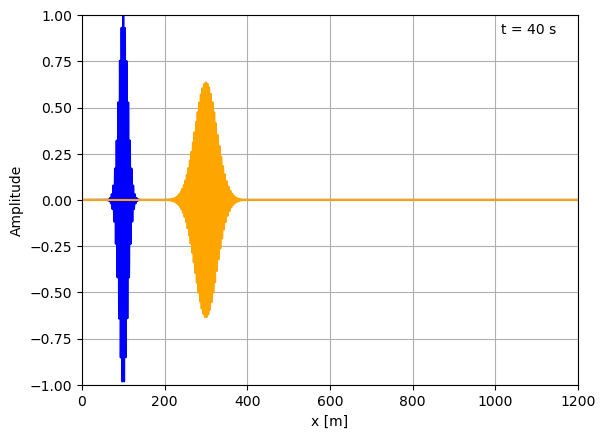

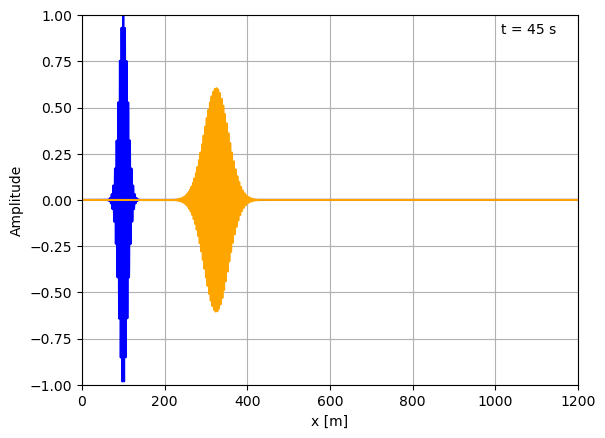

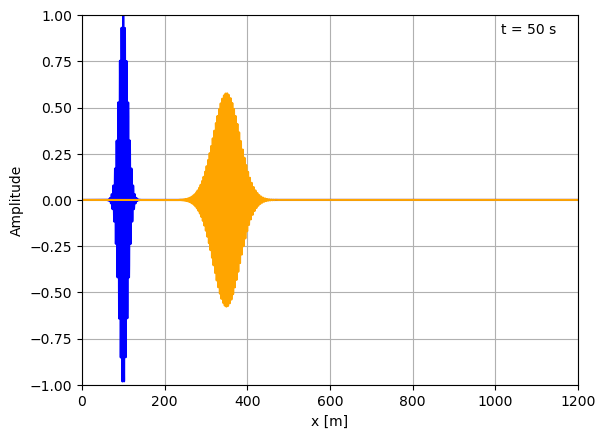

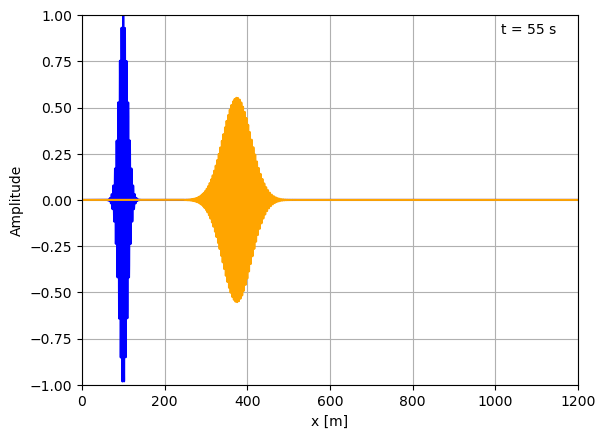

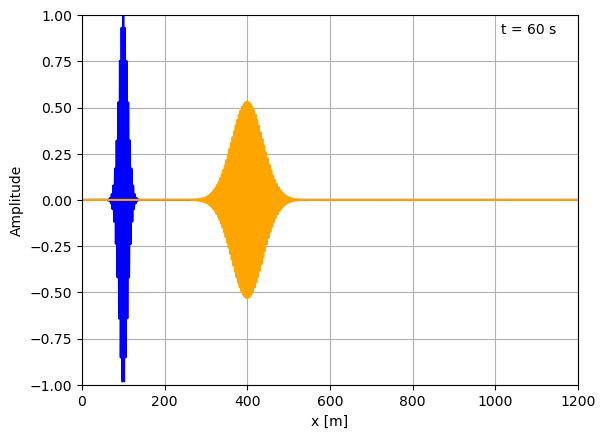

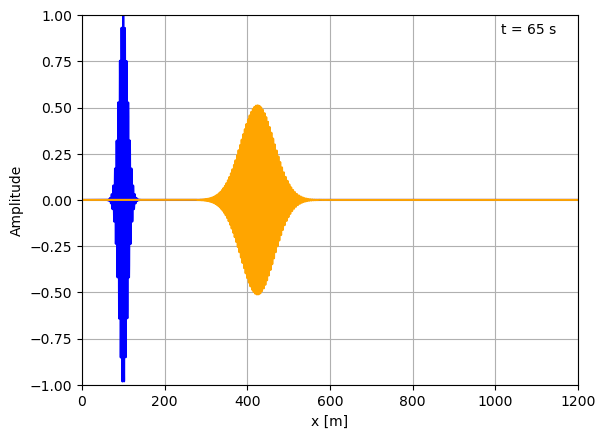

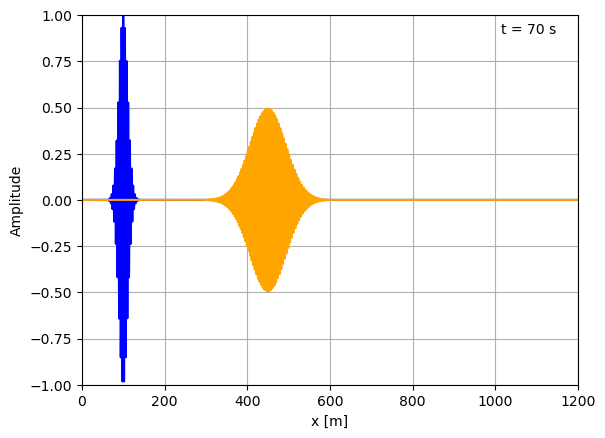

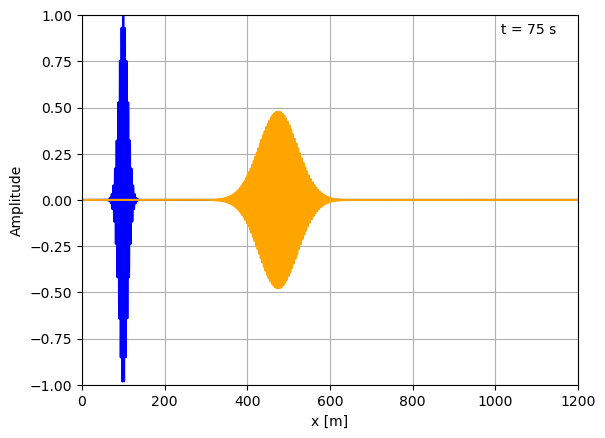

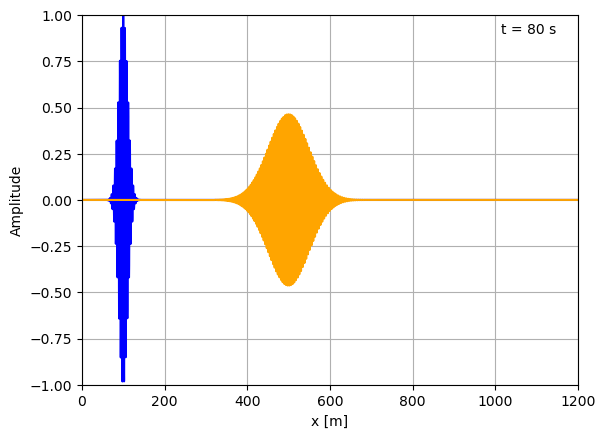

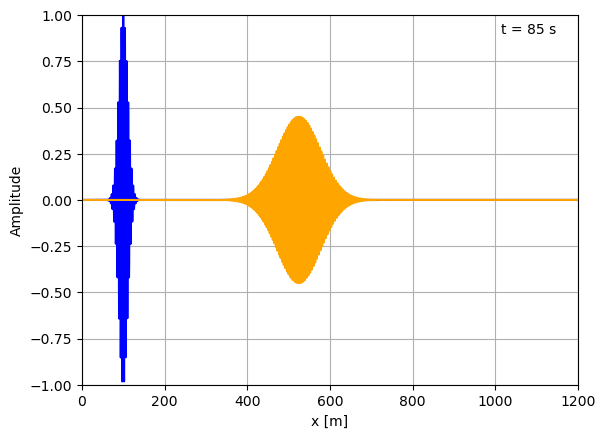

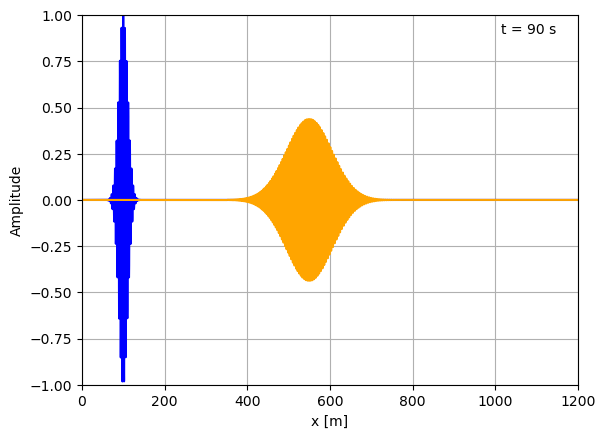

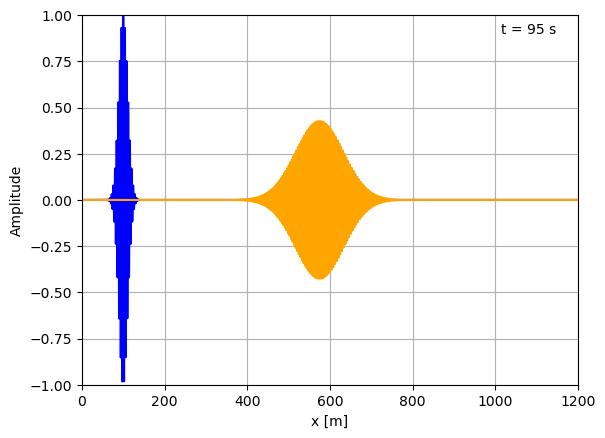

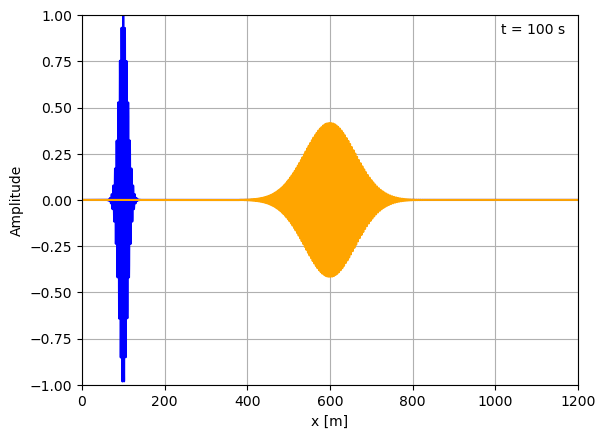

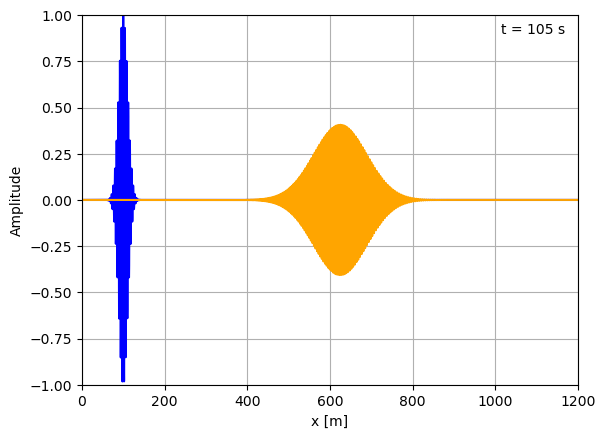

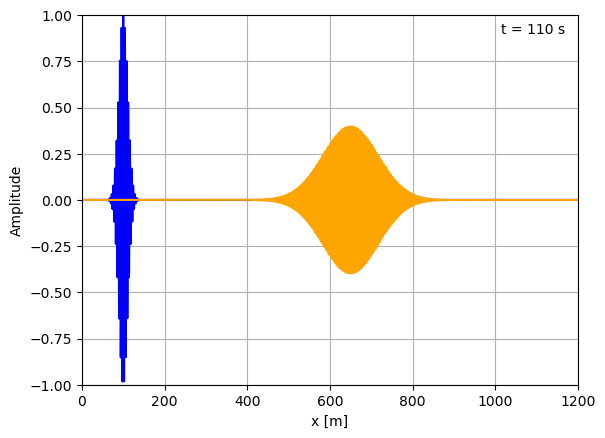

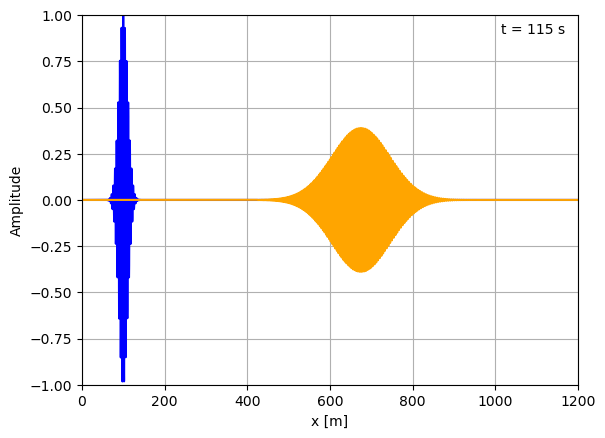

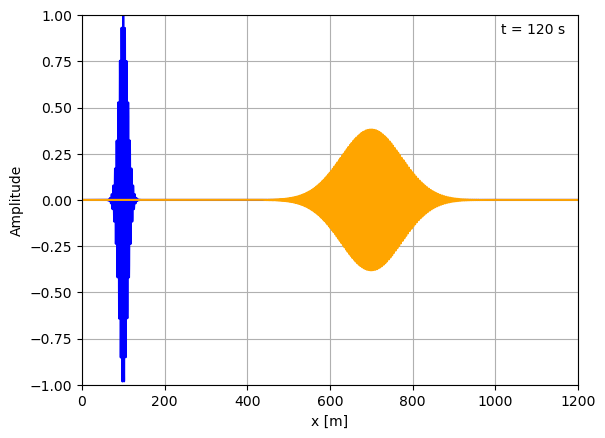

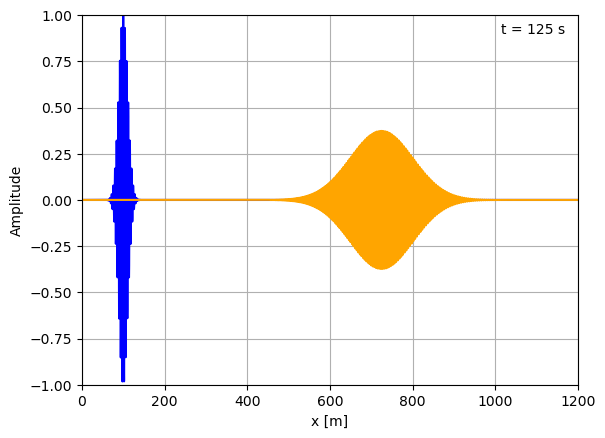

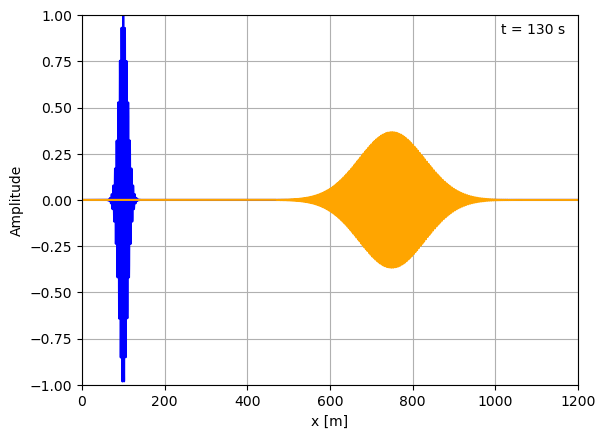

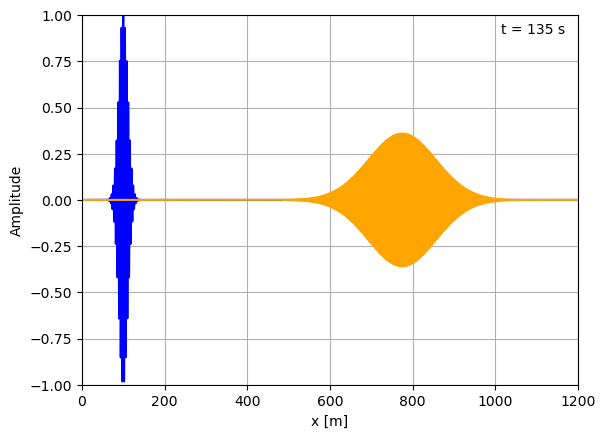

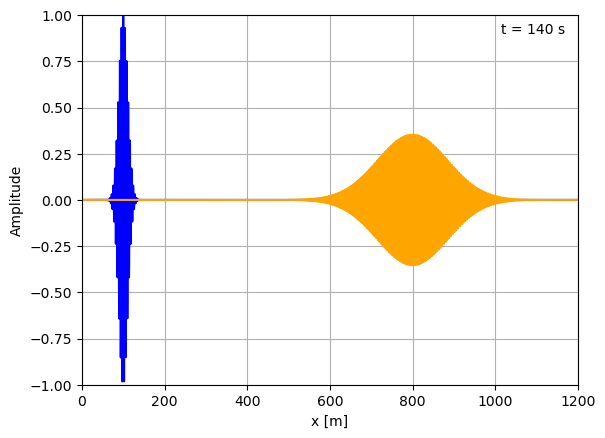

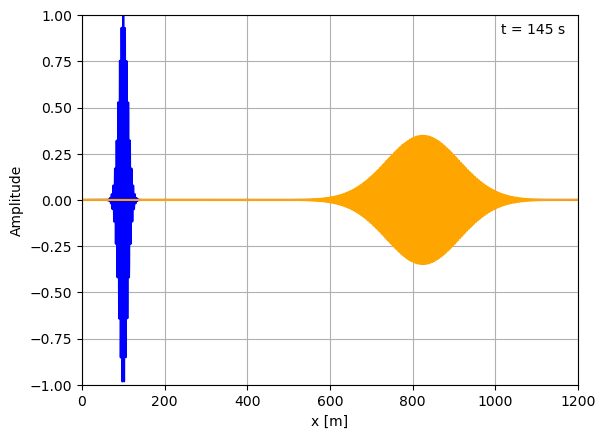

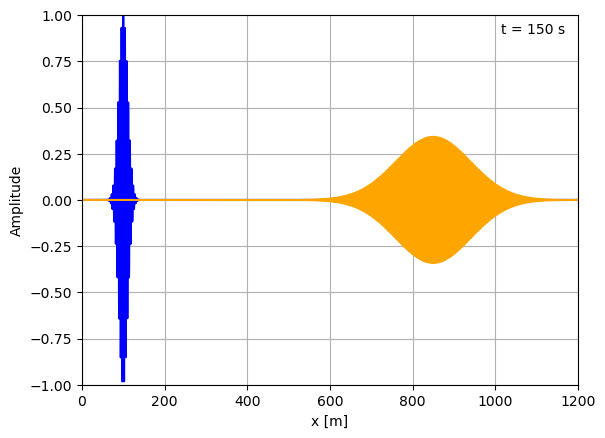

In [7]:
plt.figure("Wave packet propagation")
plt.grid(True)
plt.axis([0, 1200, -1, 1])
plt.xlabel("x [m]")
plt.ylabel("Amplitude")
plt.plot(x, np.real(psi_inp))

# Blaue Startwelle speichern
psi_start = np.real(psi_inp)

izend = 31
t_vals = np.zeros(izend)
psi_out = np.zeros((izend, xsteps))
tstr = [""]*izend

for iz in range(izend):
    t_vals[iz] = iz * 5              # time in s
    tempstr = f"{t_vals[iz]:.5g} s"
    tstr[iz] = f"t = {tempstr}"
    psi_out[iz,:] = np.real(np.fft.ifft(PSI_inp * np.exp(-1j * omega * t_vals[iz])))

for iz in range(izend):
    plt.cla()
    plt.grid(True)
    plt.axis([0, 1200, -1, 1])
    plt.xlabel("x [m]")
    plt.ylabel("Amplitude")
    # Startwelle immer wieder zeichnen (blau)
    plt.plot(x, psi_start, color='blue', label='Start position')
    plt.plot(x, psi_out[iz,:], color='orange')
    plt.text(1015, 0.9, tstr[iz])
    plt.pause(0.2)
        
plt.show()